In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from diffusers import DDPMScheduler, EulerDiscreteScheduler, ScoreSdeVeScheduler

Instantiating the schedulers.

In [2]:
#| echo: true
num_steps = 100
normalized_time = np.linspace(0, 1, num_steps)

ddpm = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
ddpm.set_timesteps(num_steps)

edm = EulerDiscreteScheduler(num_train_timesteps=1000, use_karras_sigmas=True)
edm.set_timesteps(num_steps)

smld = ScoreSdeVeScheduler(num_train_timesteps=1000)
smld.set_timesteps(num_steps)

Extracting the noise schedules from each method.

In [5]:
#| echo: true
alpha_bar = ddpm.alphas_cumprod.numpy()[ddpm.timesteps.numpy()][::-1]
alpha_ddpm = np.sqrt(alpha_bar)
sigma_ddpm = np.sqrt(1 - alpha_bar)

sigma_edm = edm.sigmas.numpy()[::-1][1:]
alpha_edm = np.ones_like(sigma_edm)

sigma_min = smld.config.sigma_min
sigma_max = smld.config.sigma_max
sigma_smld = sigma_min * (sigma_max / sigma_min) ** normalized_time
alpha_smld = np.ones_like(sigma_smld)

t_subvp = np.linspace(0.001, 0.999, num_steps)
alpha_subvp = 1 - t_subvp
sigma_subvp = t_subvp

Plotting the schedules.

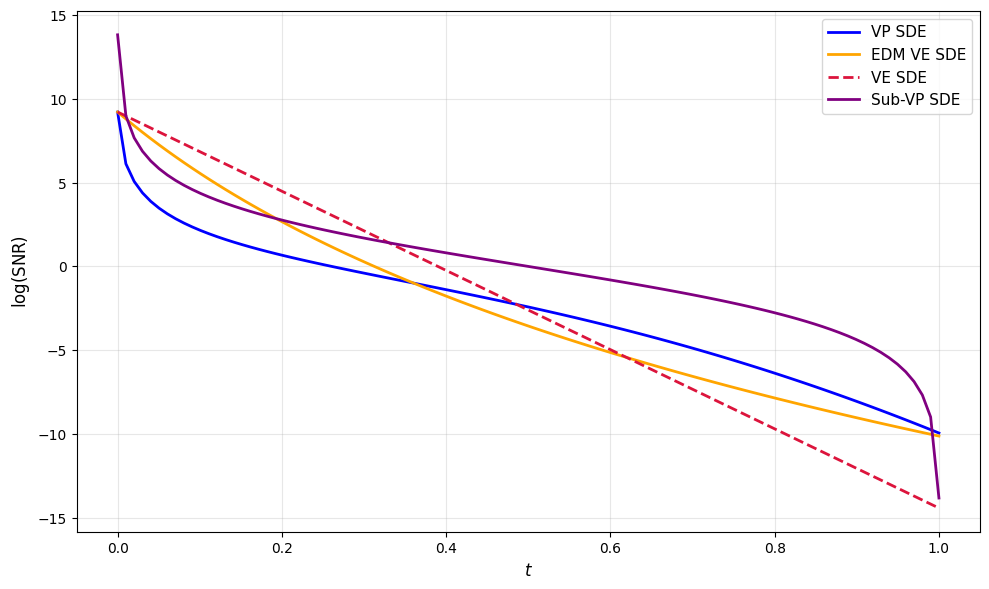

In [6]:
#| echo: true
def log_snr(alpha, sigma):
    return 2 * np.log(alpha / sigma)

plt.figure(figsize=(10, 6))

plt.plot(normalized_time, log_snr(alpha_ddpm, sigma_ddpm), label="VP SDE", linewidth=2, c="blue")
plt.plot(normalized_time, log_snr(alpha_edm, sigma_edm), label="EDM VE SDE", linewidth=2, c="orange")
plt.plot(normalized_time, log_snr(alpha_smld, sigma_smld), label="VE SDE", linewidth=2, linestyle='--', c="crimson")
plt.plot(normalized_time, log_snr(alpha_subvp, sigma_subvp), label="Sub-VP SDE", linewidth=2, c="purple")

plt.xlabel(r"$t$", fontsize=12)
plt.ylabel(r"$\log(\text{SNR})$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()